# Electron Beam–Based Alignment (eBBA) Tutorial

In this tutorial, we demonstrate how to use Ocelot to perform an electron beam–based alignment (BBA) procedure and obtain all necessary components for alignment analysis.

The approach follows P. Emma et al., NIM A 429 (1999) 407–413 , where offsets of beam position monitors (BPMs) and quadrupole magnets are deduced from beam trajectory measurements at different beam energies.

In this example we do not interface with an accelerator control system — instead, BPM readings are simulated using Ocelot functions.

> **Note:**  
> The `bba` module is available starting from version **25.07.2** and higher.  
> At the time of writing, it resides in the *development branch* and may change without backward compatibility.

---
## 1. Principle of the Method

The BPM readings of the electron beam in the undulator section can be written as:

$$
m_x = R_x x_{\text{init}} + P_x d_x - b_x, 
$$
$$
m_y = R_y y_{\text{init}} + P_y d_y - b_y,
$$

where:
* $m_x, m_y$ – measured BPM signals (horizontal, vertical),
* $x_{\text{init}} = [x_0, x_0’]$,  $y_{\text{init}} = [y_0, y_0’]$ – initial orbit coordinates at the lattice entrance,
* $d_x, d_y$ – quadrupole offsets (unknowns to determine),
* $b_x, b_y$ – BPM offsets (unknowns to determine),
* $R_{x,y}$ – launch response matrices ($N_{\text{BPM}}!\times!2$),
* $P_{x,y}$ – quadrupole response matrices ($N_{\text{BPM}}!\times!N_{\text{quad}}$).

### Quadrupole Response Matrix Elements

For each BPM $i$ and quadrupole $j$, the matrix elements are:

$$
P_x(i,j) = (1 - Q_{11}) R_{11} - Q_{21} R_{12},
$$
$$
P_y(i,j) = (1 - Q_{33}) R_{33} - Q_{43} R_{34},
$$

where $Q_{mn}$ are the transfer-matrix of quadrupole $j$,
and $R_{mn}$ are the transport coefficients from that quadrupole end to BPM $i$  


### Energy Dependence

Beam-based alignment exploits the fact that quadrupole-induced kicks scale with inverse momentum, while BPM offsets do not.
By recording trajectories at multiple beam energies, we can disentangle these effects.

Both $R_{x,y}$ and $P_{x,y}$ depend on the beam energy through optics scaling, whereas BPM offsets $b_{x,y}$ remain constant.

Ocelot’s bba module automatically computes these energy-dependent matrices from the lattice, enabling a full reconstruction of BPM and quadrupole offsets using simulated data prior to applying the method experimentally.

### Multi-Energy Linear System and Launch Assumptions

For each energy setting $s = 1, \ldots, S$:

$$
m_x^{(s)} = R_x^{(s)} x_{\text{init}}^{(s)} + P_x^{(s)} d_x - b_x,
$$
$$
m_y^{(s)} = R_y^{(s)} y_{\text{init}}^{(s)} + P_y^{(s)} d_y - b_y.
$$

This highlights the key assumptions:
* $d_x, d_y$ (quadrupole offsets) are common for all energies,
* $b_x, b_y$ (BPM offsets) are common for all energies,
* $R_{x,y}^{(s)}$ and $P_{x,y}^{(s)}$ are energy dependent,
* $x_{\text{init}}^{(s)}$, $y_{\text{init}}^{(s)}$ may be either common or energy dependent.

In the **energy-dependent launch** model, the stacked horizontal system is:

$$
\begin{bmatrix}
m_x^{(1)} \\
m_x^{(2)} \\
\vdots \\
m_x^{(S)}
\end{bmatrix}
=
\begin{bmatrix}
R_x^{(1)} & 0 & \cdots & 0 \\
0 & R_x^{(2)} & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & R_x^{(S)}
\end{bmatrix}
\begin{bmatrix}
x_{\text{init}}^{(1)} \\
x_{\text{init}}^{(2)} \\
\vdots \\
x_{\text{init}}^{(S)}
\end{bmatrix}
+
\begin{bmatrix}
P_x^{(1)} \\
P_x^{(2)} \\
\vdots \\
P_x^{(S)}
\end{bmatrix} d_x
+
\begin{bmatrix}
-I \\
-I \\
\vdots \\
-I
\end{bmatrix} b_x.
$$

The same structure applies in the vertical plane with $m_y, R_y, y_{\text{init}}, P_y, d_y, b_y$.

In Ocelot this is controlled by `per_measurement_launch`:

```python
# Shared launch (default): one x_init and one y_init for all energies
A = bba.build_full_matrix(R=[Rxs, Rys], P=[Pxs, Pys])

# Energy-dependent launch: independent x_init^(s), y_init^(s)
A = bba.build_full_matrix(R=[Rxs, Rys], P=[Pxs, Pys], per_measurement_launch=True)
```

When extracting the solution in this mode, the number of measurements must be provided:

```python
Xinit_est, Yinit_est, dx_est, dy_est, bx_est, by_est = bba.extract_solution(
    X_est,
    Nquad=len(quads),
    Nbpm=len(bpms),
    n_measurements=len(energies),
    per_measurement_launch=True,
)
```

## 2. Lattice Setup and Twiss Parameters

sase1 lattice can be downloaded from [the EuXFEL Ocelot lattice repository](https://github.com/ocelot-collab/EuXFEL-Lattice/blob/main/lattices/longlist_2024_07_04/sase1.py)

In [1]:
import sys
sys.path.insert(0, "/Users/tomins/Nextcloud/DESY/repository/ocelot")
import sase1
from ocelot import *
from ocelot.gui import *
from ocelot.utils import bba

initializing ocelot...


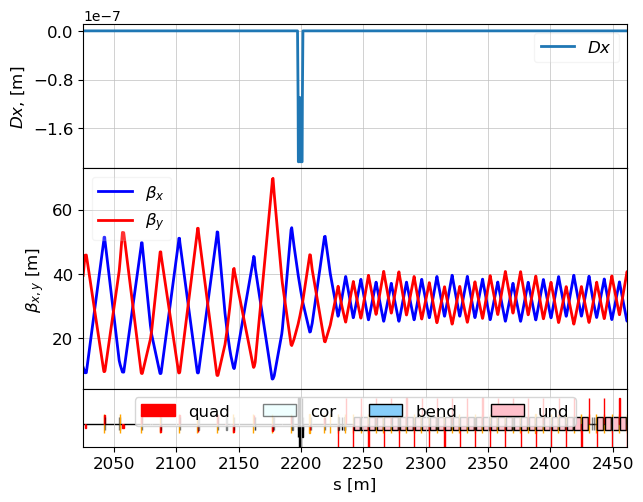

In [2]:
lat = MagneticLattice(sase1.cell)

tws = twiss(lat, sase1.tws0)
plot_opt_func(lat, tws)
plt.show()

## 3. Selecting Quadrupoles and BPMs


In [3]:
quads = []
bpms = []
for e in lat.sequence:
    if isinstance(e, Quadrupole):
        if ".SA1" in e.id:
            quads.append(e)
    if isinstance(e, Monitor):
        if ".SA1" in e.id :
            bpms.append(e)
print(f"n bpms = {len(bpms)}")
print(f"n quads = {len(quads)}")


n bpms = 37
n quads = 37


## 4. Response Matrices for Multiple Energies

In a typical BBA, beam energy is varied while quadrupole currents remain fixed.
This allows one to separate BPM offsets (energy-independent) from quadrupole kicks (∝ 1/E).

In simulation, we instead fix the lattice energy and scale quadrupole strengths inversely with energy:

$$
k_1(E) = k_{1,\text{ref}}\frac{E_{\text{ref}}}{E},
$$

so that for lower energies, the same quadrupole current produces a stronger focusing effect — exactly as in the real accelerator.


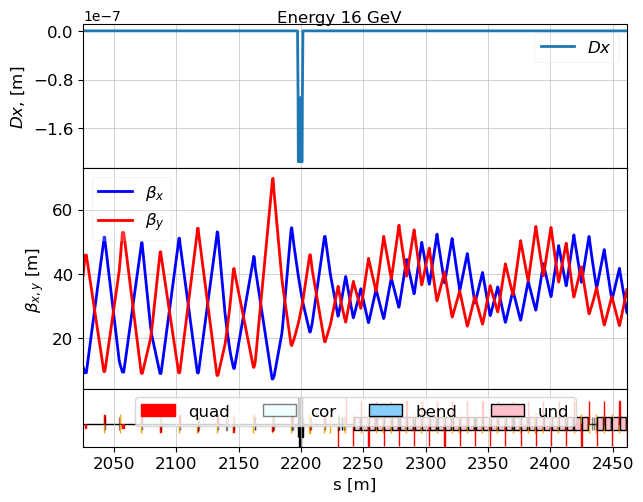

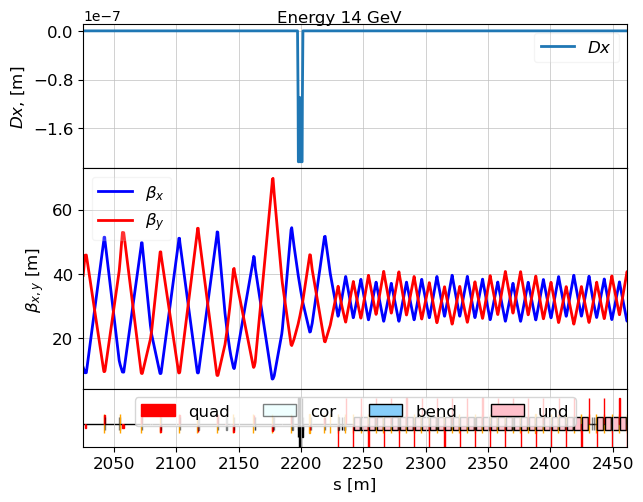

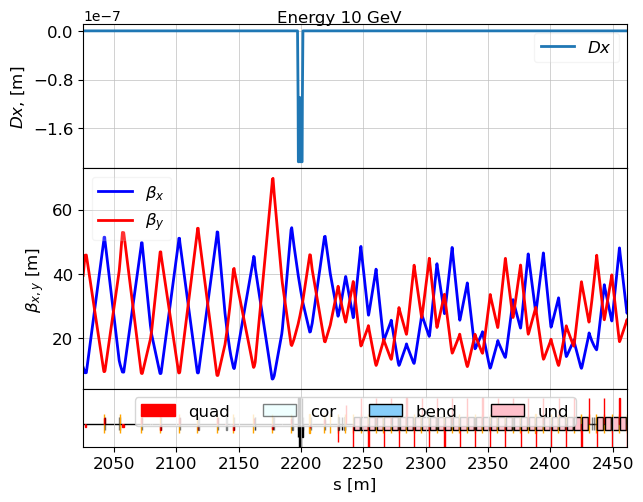

In [4]:
Eref = 14 # GeV
energies = [16, 14, 10] # GeV 
Rxs, Rys, Pxs, Pys = bba.generate_response_matrices_for_energies(lat, quads, bpms, energies, Eref, plot=True, tws0=sase1.tws0)

## 5. Building the Full System

For each energy setting $s = 1, \,\ldots,\, S$, the BPM equations are:

$$
\begin{aligned}
m_x^{(s)} &= R_x^{(s)} \, x_{\text{init}}^{(s)} + P_x^{(s)} \, d_x - b_x, \\
m_y^{(s)} &= R_y^{(s)} \, y_{\text{init}}^{(s)} + P_y^{(s)} \, d_y - b_y.
\end{aligned}
$$

Stacking all energies gives one global linear system:

$$
M = A \, X,
$$

with plane-wise blocks:

$$
A_x = [\,L_x\;\;P_{x,\text{all}}\;\;B_x\,],
\qquad
A_y = [\,L_y\;\;P_{y,\text{all}}\;\;B_y\,],
$$

$$
B_x = B_y =
\begin{bmatrix}
-I \\
-I \\
\vdots \\
-I
\end{bmatrix}
\text{ (}S\text{ blocks)}.
$$

The difference between the two models is in $L_x, L_y$.

### Case A: Shared Launch for All Energies (default)

Assume:

$$
x_{\text{init}}^{(1)} = \cdots = x_{\text{init}}^{(S)} = x_{\text{init}},
\qquad
y_{\text{init}}^{(1)} = \cdots = y_{\text{init}}^{(S)} = y_{\text{init}}.
$$

Then:

$$
L_x =
\begin{bmatrix}
R_x^{(1)} \\
R_x^{(2)} \\
\vdots \\
R_x^{(S)}
\end{bmatrix}
\in \mathbb{R}^{S N_{\text{BPM}} \times 2},
\qquad
L_y =
\begin{bmatrix}
R_y^{(1)} \\
R_y^{(2)} \\
\vdots \\
R_y^{(S)}
\end{bmatrix}
\in \mathbb{R}^{S N_{\text{BPM}} \times 2}.
$$

Number of unknown columns:

$$
N_{\text{col,shared}} = 2\times(2 + N_{\text{BPM}} + N_{\text{quad}}).
$$

Ocelot call:

```python
A = bba.build_full_matrix(R=[Rxs, Rys], P=[Pxs, Pys])
```

### Case B: Energy-Dependent Launch

Assume $x_{\text{init}}^{(s)}$ and $y_{\text{init}}^{(s)}$ are independent for each energy.

Then:

$$
L_x = \operatorname{blockdiag}(R_x^{(1)},\ldots,R_x^{(S)})
\in \mathbb{R}^{S N_{\text{BPM}} \times 2S},
$$

$$
L_y = \operatorname{blockdiag}(R_y^{(1)},\ldots,R_y^{(S)})
\in \mathbb{R}^{S N_{\text{BPM}} \times 2S}.
$$

Number of unknown columns:

$$
N_{\text{col,per-launch}} = 2\times(2S + N_{\text{BPM}} + N_{\text{quad}}).
$$

Ocelot calls:

```python
A = bba.build_full_matrix(R=[Rxs, Rys], P=[Pxs, Pys], per_measurement_launch=True)
```

```python
Xinit_est, Yinit_est, dx_est, dy_est, bx_est, by_est = bba.extract_solution(
    X_est,
    Nquad=len(quads),
    Nbpm=len(bpms),
    n_measurements=len(energies),
    per_measurement_launch=True,
)
```

### Matrix Size in This Example

Here $N_{\text{BPM}}=37$, $N_{\text{quad}}=37$, and $S=3$:

- Shared launch: $N_{\text{col,shared}} = 2\times(2+37+37)=152$
- Energy-dependent launch: $N_{\text{col,per-launch}} = 2\times(2\times3+37+37)=160$
- Rows in both cases:

$$
N_{\text{row}} = 2\times S\times N_{\text{BPM}} = 2\times3\times37 = 222.
$$


In [5]:
A = bba.build_full_matrix(R=[Rxs, Rys], P=[Pxs, Pys], per_measurement_launch=True)

print(f"Shape A = [{A.shape}]")

Shape A = [(222, 160)]


## 6. Introducing Offsets and Simulating BPM Readings

In [6]:
# generate quads offsets
dx, dy = bba.get_random_offsets(elements=quads, sigma_x=100e-6, sigma_y=100e-6, n_sigma=3.0)
# introduce them in quadrupoles
for i, q in enumerate(quads):
    q.dx = dx[i]
    q.dy = dy[i]
    
# generate BPM offsets
bx, by = bba.get_random_offsets(elements=bpms, sigma_x=100e-6, sigma_y=100e-6, n_sigma=3.0)
#We do not need to introduce in BMPs since we have a function to read orbit which will take care of it

## 7. Getting BPM Readings for Different Beam Energies

This step is conceptually similar to generating the response matrices.  
The function:

```python
read_bpm_trajectories_vs_energy()
```
returns the simulated BPM readings *Mx* and *My* for several beam energies —
in the same way that we obtained the response matrices for multiple energy settings.

When the argument `plot=True` is enabled, the function displays the true beam trajectories with misaligned quadrupoles.
The markers represent the BPM readings, which include additional BPM offsets.

Because of these offsets, the plotted beam trajectories (continuous lines) and the BPM readings (points) do not coincide —
illustrating the difference between the actual beam orbit and what the BPMs measure.

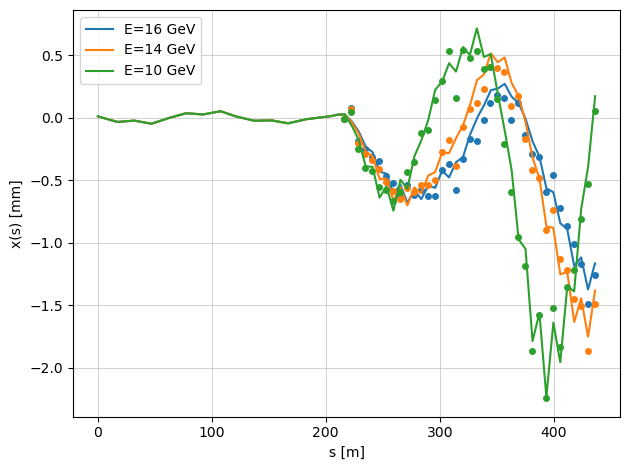

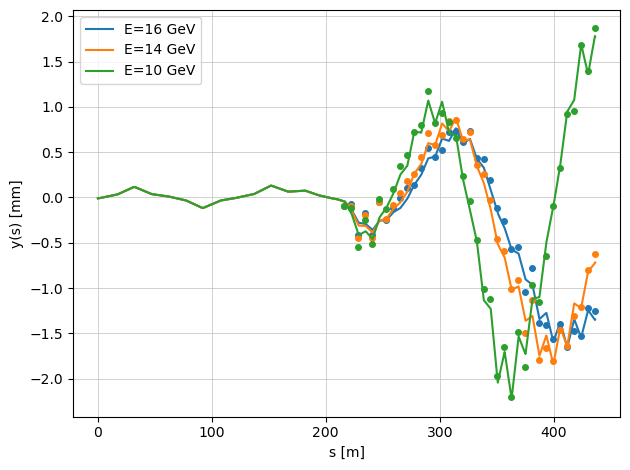

In [7]:
Xinit=(10e-6, -3e-6)
Yinit=(-10e-6, 2e-6)
Mx, My = bba.read_bpm_trajectories_vs_energy(
    lat,
    quads,
    bpms,
    energies,
    Eref,
    Xinit=Xinit, 
    Yinit=Yinit,
    bpm_offset_x=bx,
    bpm_offset_y=by,
    noise_rms=(2e-6, 2e-6), # BPM accuracy
    noise_truncated=3,
    launch_jitter = (1e-6, 0.0, 1e-6, 0.0), # launch orbit jitter in m or rad (x, x', y, y')
    launch_jitter_truncated = 3.0,
    plot=True,
)

## 8. Solving the System of Linear Equations

As discussed above, we need to solve the following linear system:

$$
M = A \, X,
$$

where:
- $ M $ — the vector of measured BPM readings (horizontal and vertical),
- $ A $ — the full response matrix built from the launch, quadrupole, and BPM offset contributions,
- $ X $ — the unknown vector containing initial beam parameters, quadrupole offsets, and BPM offsets.

To obtain $ X $, we use the **Singular Value Decomposition (SVD)** method, which allows us to compute a stable **pseudo-inverse** of the matrix $ A $.  
This approach is particularly useful when the system is overdetermined or when $ A $ is ill-conditioned.

The estimated solution can be written as:

$$
X_{\text{est}} = \text{solve\_svd}(A, M, rcutoff = 1 \times 10^{-4}),
$$

where `rcutoff` defines the relative threshold for small singular values to be ignored (regularization).

Before solving, we must first build the measurement vector $ M $, which combines all BPM readings for the different energy settings.

In [ ]:
Mx = np.hstack(Mx)
My = np.hstack(My)
M = np.hstack([Mx, My])
print(f"M shape = {M.shape}")

X_est = bba.solve_svd(A=A, M=M, rcutoff=1e-4, print_spectrum=False)

Xinit_est, Yinit_est, dx_est, dy_est, bx_est, by_est = bba.extract_solution(X_est, 
                                                                            Nquad=len(quads), 
                                                                            Nbpm=len(bpms), 
                                                                            n_measurements=len(energies),
                                                                            per_measurement_launch=True)

## 9. Plot results

X:
Ground truth (1e-05, -3e-06)
Estimation [[-3.57856011e-05  1.43998986e-06]
 [-3.90964005e-05  1.98578083e-06]
 [-5.05675626e-05  3.52718064e-06]]
Y:
Ground truth (-1e-05, 2e-06)
Estimation [[-2.91191849e-05  2.73344374e-06]
 [-3.90965344e-05  2.70252524e-06]
 [-7.62605988e-05  2.18279427e-06]]


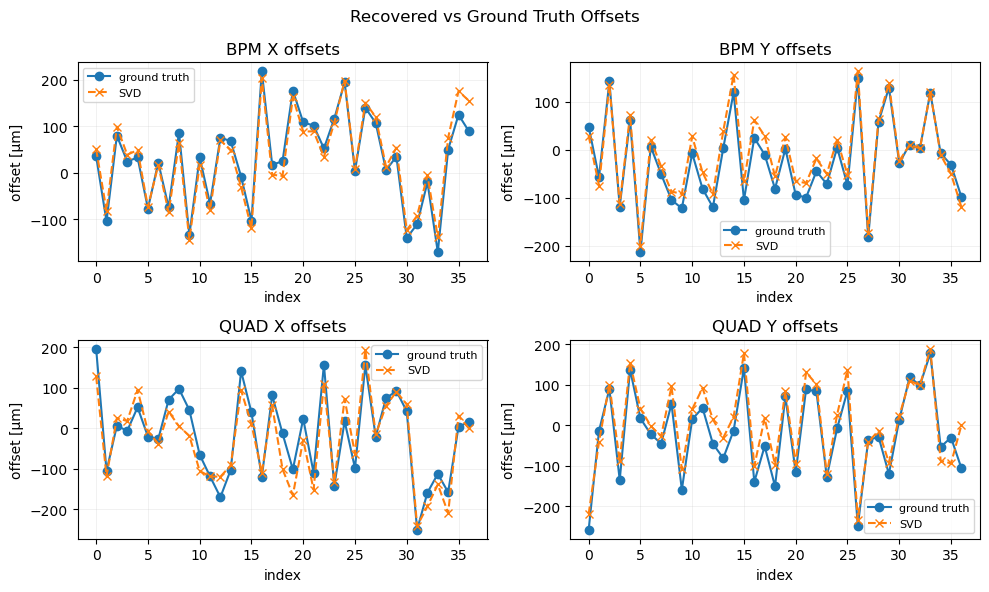

In [9]:
bpm_ids = [bpm.id for bpm in bpms]
quad_ids = [q.id for q in quads]

# ======== Plotting ========
print("X:")
print(f"Ground truth {Xinit}" )
print(f"Estimation {Xinit_est}" )
print("Y:")
print(f"Ground truth {Yinit}" )
print(f"Estimation {Yinit_est}" )
fig, axs = plt.subplots(2, 2, figsize=(10, 6), tight_layout=True)
axs = axs.ravel()

def plot_offsets(ax, gt, est1, ids, title, est2=None, label1="SVD", label2=None):
    ax.plot(gt*1e6, "o-", label="ground truth")
    ax.plot(est1*1e6, "x--", label=label1)
    if est2 is not None:
        ax.plot(svd_curve*1e6, "s:", label=label2)
    ax.set_title(title)
    ax.set_xlabel("index")
    ax.set_ylabel("offset [µm]")
    if len(ids) < 20:
        ax.set_xticks(range(len(ids)))
        ax.set_xticklabels(ids, rotation=90, fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plot_offsets(axs[0], bx, bx_est, bpm_ids, "BPM X offsets", est2=None)
plot_offsets(axs[1], by, by_est, bpm_ids, "BPM Y offsets", est2=None)
plot_offsets(axs[2], dx, dx_est, quad_ids, "QUAD X offsets", est2=None)
plot_offsets(axs[3], dy, dy_est, quad_ids, "QUAD Y offsets", est2=None)

plt.suptitle("Recovered vs Ground Truth Offsets", fontsize=12)
plt.show()

# Second iteration. 
### Calculate new offsets
> **Note:**
> for the quads we need to introduce offsets manually

In [12]:
dx1 = dx - dx_est
dy1 = dy - dy_est
bx1 = bx - bx_est
by1 = by - by_est
# introduce them in quadrupoles
for i, q in enumerate(quads):
    q.dx = dx1[i]
    q.dy = dy1[i]

### Read BMPs 
here we need to introduce new bpm offsets

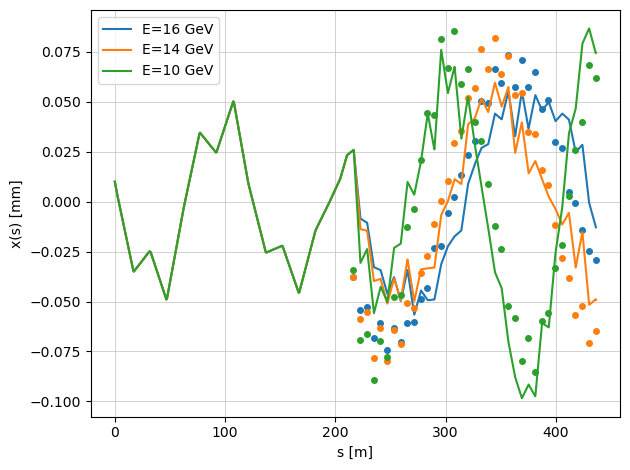

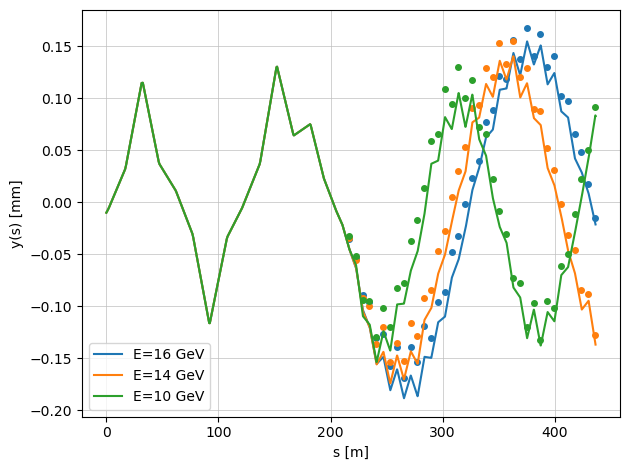

In [13]:
Mx, My = bba.read_bpm_trajectories_vs_energy(
    lat,
    quads,
    bpms,
    energies,
    Eref,
    Xinit=Xinit, 
    Yinit=Yinit,
    bpm_offset_x=bx1,
    bpm_offset_y=by1,
    noise_rms=(2e-6, 2e-6), # BPM accuracy
    noise_truncated=3,
    launch_jitter = (1e-6, 0.0, 1e-6, 0.0), # launch orbit jitter in m or rad (x, x', y, y')
    launch_jitter_truncated = 3.0,
    plot=True,
)

### Find solution

In [14]:
Mx = np.hstack(Mx)
My = np.hstack(My)
M = np.hstack([Mx, My])
print(f"M shape = {M.shape}")

X_est = bba.solve_svd(A=A, M=M, rcutoff=1e-5, print_spectrum=False)

Xinit_est, Yinit_est, dx_est, dy_est, bx_est, by_est = bba.extract_solution(X_est, 
                                                                            Nquad=len(quads), 
                                                                            Nbpm=len(bpms),
                                                                            n_measurements=len(energies),
                                                                            per_measurement_launch=True)

M shape = (222,)


### Plot results

X:
Ground truth (1e-05, -3e-06)
Estimation [[-1.76619907e-05  1.87518164e-06]
 [-2.16755902e-05  2.33286884e-06]
 [-3.38652851e-05  3.55366597e-06]]
Y:
Ground truth (-1e-05, 2e-06)
Estimation [[-1.72424186e-05  9.28158905e-07]
 [-1.61241822e-05  8.95006095e-07]
 [-2.02213747e-06  9.80604390e-07]]


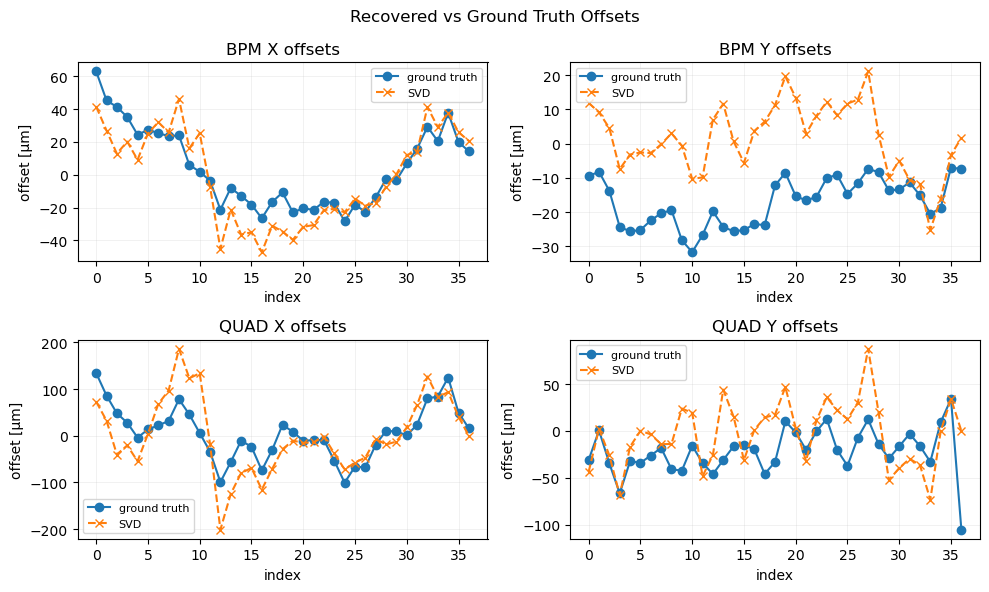

In [15]:
bpm_ids = [bpm.id for bpm in bpms]
quad_ids = [q.id for q in quads]

# ======== Plotting ========
print("X:")
print(f"Ground truth {Xinit}" )
print(f"Estimation {Xinit_est}" )
print("Y:")
print(f"Ground truth {Yinit}" )
print(f"Estimation {Yinit_est}" )
fig, axs = plt.subplots(2, 2, figsize=(10, 6), tight_layout=True)
axs = axs.ravel()


plot_offsets(axs[0], bx1, bx_est, bpm_ids, "BPM X offsets", est2=None)
plot_offsets(axs[1], by1, by_est, bpm_ids, "BPM Y offsets", est2=None)
plot_offsets(axs[2], dx1, dx_est, quad_ids, "QUAD X offsets", est2=None)
plot_offsets(axs[3], dy1, dy_est, quad_ids, "QUAD Y offsets", est2=None)

plt.suptitle("Recovered vs Ground Truth Offsets", fontsize=12)
plt.show()